**importing important libraries**

In [17]:
# importing libraries like google drive
# pandas
# matplotlib and seaborn
# numpy

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns



**calling the dataset**

In [ ]:
epma = pd.read_excel('/content/Combined Datasets EPMA (1).xlsx',
                             sheet_name= 'epma'
                             )

**converting int dtype of column t into float**

In [ ]:
epma['T'] = epma['T'].astype(float)

epma.dtypes

,0
SAMPLE,object
NiO,float64
F,float64
CaO,float64
SiO2,float64
Cr2O3,float64
Na2O,float64
TiO2,float64
V2O3,float64
MnO,float64


#**Data preprocessing**
normalization and standardisation(z-score)

**slicing the data for preprocessing**

In [ ]:
epma_no_sample = epma.iloc[:,1:15]

epma1 = epma_no_sample

epma1

,NiO,F,CaO,SiO2,Cr2O3,Na2O,TiO2,V2O3,MnO,MgO,ZnO,FeO,Al2O3,K2O
0,0.005,0.023,22.625,44.409,0.231,0.758,3.365,0.051,0.081,11.749,0.000,5.069,11.660,0.001
1,0.000,0.124,22.752,47.643,0.302,0.764,2.058,0.031,0.017,13.116,0.046,4.967,7.996,0.007
2,0.014,0.000,22.711,49.580,0.189,0.539,1.448,0.033,0.141,14.243,0.000,4.977,5.495,0.004
3,0.000,0.000,23.481,51.316,0.100,0.534,0.057,0.050,0.421,7.376,0.000,16.404,0.564,0.009
4,0.000,0.000,23.601,51.941,0.118,0.423,0.139,0.074,0.388,7.826,0.074,15.199,0.536,0.003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,0.000,0.000,23.304,47.393,0.026,0.748,1.640,0.018,0.106,11.943,0.009,7.220,7.173,0.002
414,0.009,0.000,23.196,47.737,0.092,0.603,1.741,0.035,0.136,12.672,0.000,6.285,6.877,0.007
415,0.011,0.098,23.203,46.864,0.031,0.646,1.915,0.045,0.100,13.031,0.000,5.427,8.015,0.016
416,0.018,0.000,23.210,45.340,0.071,0.644,2.295,0.077,0.067,11.945,0.000,6.160,9.679,0.019


**checking the skewness before applying data transformation**

In [ ]:
# Analyze the data in the 'epma1' sheet to determine suitable transformations

epma1.describe()

# Check for skewness in numerical columns
skewness = epma1.skew(numeric_only=True)

skewness


,0
NiO,1.480975
F,2.259260
CaO,-0.270730
SiO2,-0.318042
Cr2O3,2.094826
Na2O,2.384579
TiO2,0.353124
V2O3,0.501308
MnO,2.221713
MgO,-0.929261


**Applying normalization to features where skewness more than 1 or less then 1**


In [ ]:
epma.columns

Index(['SAMPLE', 'NiO', 'F', 'CaO', 'SiO2', 'Cr2O3', 'Na2O', 'TiO2', 'V2O3',
       'MnO', 'MgO', 'ZnO', 'FeO', 'Al2O3', 'K2O', 'T'],
      dtype='object')

**visualization of epma1 data**

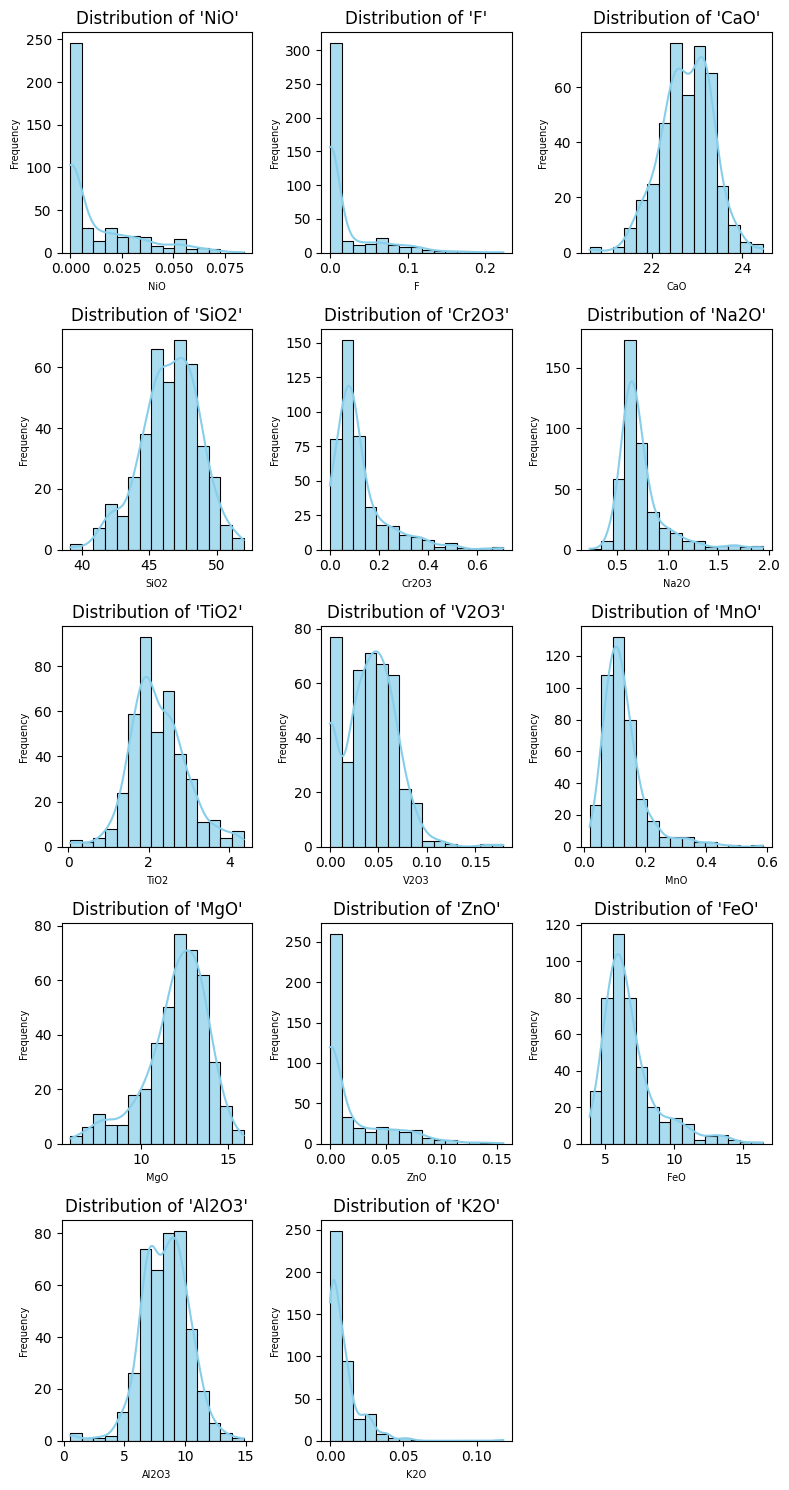

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Function to plot histograms and boxplots for each feature
def plot_distribution(data):
    """
    Plots histograms with KDEs for each column in the dataset.

    Parameters:
    - data: pandas DataFrame containing numerical columns to visualize.

    Displays:
    - A grid of subplots with histograms and KDEs for each column in the data.
    """
    # Number of columns to plot
    num_columns = len(data.columns)

    # Determine grid size for subplots
    num_rows = math.ceil(num_columns / 3)  # 3 columns per row

    # Create subplots
    fig, axes = plt.subplots(num_rows, 3, figsize=(8, 3 * num_rows))  # Adjust figure size
    axes = axes.flatten()  # Flatten axes for easy indexing

    for i, col in enumerate(data.columns):
        # Plot histogram with KDE
        sns.histplot(
            data[col],
            ax=axes[i],
            kde=True,
            bins=15,
            color='skyblue',
            edgecolor='black',
            alpha=0.7
        )

        # Set titles and labels
        axes[i].set_title(f"Distribution of '{col}'", fontsize=12)
        axes[i].set_xlabel(col, fontsize=7)
        axes[i].set_ylabel("Frequency", fontsize=7)

    # Hide unused axes if the grid is larger than required
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')  # Hide extra subplots

    # Adjust layout for better spacing
    plt.tight_layout()

    # Display the plots
    plt.show()

# Call the function on your dataset
plot_distribution(epma1)


**Sandardization of selected columns**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select the specified columns for standardization
columns_to_standardize = ['CaO', 'SiO2', 'TiO2', 'V2O3', 'MgO', 'Al2O3']
epma_stand = epma[columns_to_standardize]

# Apply standardization using StandardScaler
scaler = StandardScaler()
standardized_data = pd.DataFrame(scaler.fit_transform(epma_stand), columns=columns_to_standardize)

# Display the standardized dataset to the user
standardized_data


,CaO,SiO2,TiO2,V2O3,MgO,Al2O3
0,-0.246973,-0.990765,1.619148,0.370074,-0.157544,1.689299
1,-0.024945,0.500539,-0.264036,-0.352612,0.600939,-0.199910
2,-0.096623,1.393754,-1.142952,-0.280343,1.226258,-1.489459
3,1.249529,2.194281,-3.147167,0.333939,-2.583914,-4.031951
4,1.459319,2.482489,-3.029018,1.201161,-2.334231,-4.046388
...,...,...,...,...,...,...
413,0.940089,0.385256,-0.866310,-0.822357,-0.049903,-0.624260
414,0.751278,0.543886,-0.720784,-0.208075,0.354585,-0.776881
415,0.763516,0.141316,-0.470077,0.153268,0.553777,-0.190113
416,0.775753,-0.561450,0.077444,1.309564,-0.048793,0.667868


**normalization of selected columns**

In [ ]:
# Re-import necessary libraries due to reset
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


# Select the specified columns for normalization
columns_to_normalize = ['NiO', 'F', 'Cr2O3', 'Na2O', 'MnO', 'ZnO', 'FeO', 'K2O']
epma_Norm = epma[columns_to_normalize]

# Apply normalization using MinMaxScaler
scaler = MinMaxScaler()
normalized_data = pd.DataFrame(scaler.fit_transform(epma_Norm), columns=columns_to_normalize)

# Display the normalized dataset to the user
#import ace_tools as tools; tools.display_dataframe_to_user(name="Normalized EPMA Data", dataframe=normalized_data)
normalized_data

,NiO,F,Cr2O3,Na2O,MnO,ZnO,FeO,K2O
0,0.059524,0.103139,0.326733,0.310385,0.112281,0.000000,0.096669,0.008475
1,0.000000,0.556054,0.427157,0.313886,0.000000,0.294872,0.088540,0.059322
2,0.166667,0.000000,0.267327,0.182614,0.217544,0.000000,0.089337,0.033898
3,0.000000,0.000000,0.141443,0.179697,0.708772,0.000000,1.000000,0.076271
4,0.000000,0.000000,0.166902,0.114936,0.650877,0.474359,0.903969,0.025424
...,...,...,...,...,...,...,...,...
413,0.000000,0.000000,0.036775,0.304551,0.156140,0.057692,0.268091,0.016949
414,0.107143,0.000000,0.130127,0.219953,0.208772,0.000000,0.193577,0.059322
415,0.130952,0.439462,0.043847,0.245041,0.145614,0.000000,0.125199,0.135593
416,0.214286,0.000000,0.100424,0.243874,0.087719,0.000000,0.183615,0.161017


**concatinating standardized data and normalized data as epma2**

In [ ]:
import pandas as pd


# Concatenate column-wise
epma2 = pd.concat([normalized_data, standardized_data], axis=1)

epma2


,NiO,F,Cr2O3,Na2O,MnO,ZnO,FeO,K2O,CaO,SiO2,TiO2,V2O3,MgO,Al2O3
0,0.059524,0.103139,0.326733,0.310385,0.112281,0.000000,0.096669,0.008475,-0.246973,-0.990765,1.619148,0.370074,-0.157544,1.689299
1,0.000000,0.556054,0.427157,0.313886,0.000000,0.294872,0.088540,0.059322,-0.024945,0.500539,-0.264036,-0.352612,0.600939,-0.199910
2,0.166667,0.000000,0.267327,0.182614,0.217544,0.000000,0.089337,0.033898,-0.096623,1.393754,-1.142952,-0.280343,1.226258,-1.489459
3,0.000000,0.000000,0.141443,0.179697,0.708772,0.000000,1.000000,0.076271,1.249529,2.194281,-3.147167,0.333939,-2.583914,-4.031951
4,0.000000,0.000000,0.166902,0.114936,0.650877,0.474359,0.903969,0.025424,1.459319,2.482489,-3.029018,1.201161,-2.334231,-4.046388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,0.000000,0.000000,0.036775,0.304551,0.156140,0.057692,0.268091,0.016949,0.940089,0.385256,-0.866310,-0.822357,-0.049903,-0.624260
414,0.107143,0.000000,0.130127,0.219953,0.208772,0.000000,0.193577,0.059322,0.751278,0.543886,-0.720784,-0.208075,0.354585,-0.776881
415,0.130952,0.439462,0.043847,0.245041,0.145614,0.000000,0.125199,0.135593,0.763516,0.141316,-0.470077,0.153268,0.553777,-0.190113
416,0.214286,0.000000,0.100424,0.243874,0.087719,0.000000,0.183615,0.161017,0.775753,-0.561450,0.077444,1.309564,-0.048793,0.667868


**creating target column in preprocessed data**

In [ ]:
epma2['T'] = epma[['T']] #

**finally dataset ready for splitting**

In [ ]:
epma2


,NiO,F,Cr2O3,Na2O,MnO,ZnO,FeO,K2O,CaO,SiO2,TiO2,V2O3,MgO,Al2O3,T
0,0.059524,0.103139,0.326733,0.310385,0.112281,0.000000,0.096669,0.008475,-0.246973,-0.990765,1.619148,0.370074,-0.157544,1.689299,3.0
1,0.000000,0.556054,0.427157,0.313886,0.000000,0.294872,0.088540,0.059322,-0.024945,0.500539,-0.264036,-0.352612,0.600939,-0.199910,3.0
2,0.166667,0.000000,0.267327,0.182614,0.217544,0.000000,0.089337,0.033898,-0.096623,1.393754,-1.142952,-0.280343,1.226258,-1.489459,3.0
3,0.000000,0.000000,0.141443,0.179697,0.708772,0.000000,1.000000,0.076271,1.249529,2.194281,-3.147167,0.333939,-2.583914,-4.031951,3.0
4,0.000000,0.000000,0.166902,0.114936,0.650877,0.474359,0.903969,0.025424,1.459319,2.482489,-3.029018,1.201161,-2.334231,-4.046388,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,0.000000,0.000000,0.036775,0.304551,0.156140,0.057692,0.268091,0.016949,0.940089,0.385256,-0.866310,-0.822357,-0.049903,-0.624260,2.0
414,0.107143,0.000000,0.130127,0.219953,0.208772,0.000000,0.193577,0.059322,0.751278,0.543886,-0.720784,-0.208075,0.354585,-0.776881,2.0
415,0.130952,0.439462,0.043847,0.245041,0.145614,0.000000,0.125199,0.135593,0.763516,0.141316,-0.470077,0.153268,0.553777,-0.190113,2.0
416,0.214286,0.000000,0.100424,0.243874,0.087719,0.000000,0.183615,0.161017,0.775753,-0.561450,0.077444,1.309564,-0.048793,0.667868,2.0


#**Checklist before splitting the data**

1. Data Integrity

Column Consistency: Ensure all columns are properly aligned and there are no missing or misaligned columns after concatenation.
Row Consistency: Verify that the number of rows is consistent across the dataset (target variable, normalized, and standardized data).

2. Check for Missing Values

Purpose: Missing values can lead to errors during training or evaluation.

Handle missing values before splitting

Impute missing values with mean/median/mode (for features).

Drop rows with missing values in the target variable.

3. Check Target Variable Distribution

Purpose: Ensure the target variable has a balanced distribution for classification tasks.

If the dataset is imbalanced, plan to address this (e.g., oversampling, undersampling, or class weights).

4. Remove Duplicate Rows

Purpose: Duplicate rows can bias the model.

5. Ensure Proper Data Types

Purpose: Ensure all columns have the correct data types.
Convert columns to appropriate types (e.g., numeric for features, categorical for the target variable).

6. Normalize/Standardize All Features Except the Target

Purpose: Ensure all feature columns are either normalized or standardized.

Exclude the target column from transformations.
Ensure no column is double-transformed or left untransformed.

7. Check Correlations

Purpose: Avoid highly correlated features, which can introduce redundancy.

Remove one of the features in pairs with extremely high correlations (> 0.9).

8. Handle Outliers

Purpose: Outliers can distort model performance.
Action: Review standardized or normalized values for extreme deviations.
Decide to remove, cap, or transform outliers based on their impact.

9. Shuffle the Dataset

Purpose: Ensure data is randomized to avoid biases from the original order.

10. Final Dataset Review

Verify Dimensions: Ensure the dataset has the expected number of rows and columns.
Preview Data: Check the first few rows to confirm data integrity.

11. Plan the Split

Feature-Target Separation:

Ensure the target variable is separated from the features before splitting.
Stratified Splitting (if classification):
Use stratified splitting to ensure proportional representation of target classes in training and test sets.

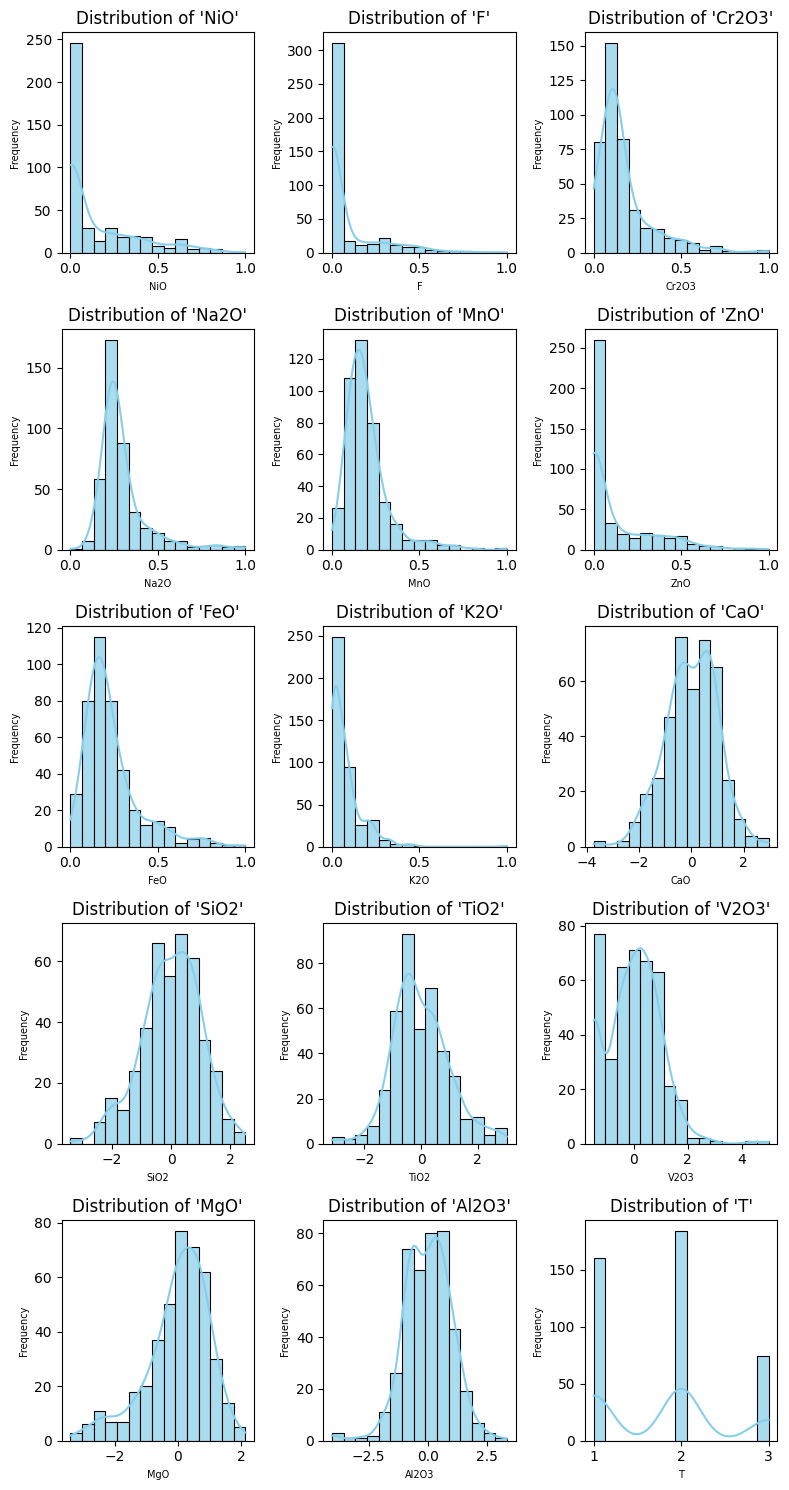

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Function to plot histograms and boxplots for each feature
def plot_distribution(data):

    # Number of columns to plot
    num_columns = len(data.columns)

    # Determine grid size for subplots
    num_rows = math.ceil(num_columns / 3)  # 3 columns per row

    # Create subplots
    fig, axes = plt.subplots(num_rows, 3, figsize=(8, 3 * num_rows))  # Adjust figure size
    axes = axes.flatten()  # Flatten axes for easy indexing

    for i, col in enumerate(data.columns):
        # Plot histogram with KDE
        sns.histplot(
            data[col],
            ax=axes[i],
            kde=True,
            bins=15,
            color='skyblue',
            edgecolor='black',
            alpha=0.7
        )

        # Set titles and labels
        axes[i].set_title(f"Distribution of '{col}'", fontsize=12)
        axes[i].set_xlabel(col, fontsize=7)
        axes[i].set_ylabel("Frequency", fontsize=7)

    # Hide unused axes if the grid is larger than required
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')  # Hide extra subplots

    # Adjust layout for better spacing
    plt.tight_layout()

    # Display the plots
    plt.show()

# Call the function on your dataset
plot_distribution(epma2)


**1. Data Integrity**

Column Consistency: Ensure all columns are properly aligned and there are no missing or misaligned columns after concatenation.
Row Consistency: Verify that the number of rows is consistent across the dataset (target variable, normalized, and standardized data).

In [ ]:
# things done before splitting the data

# Re-import necessary libraries and reload data after reset
import pandas as pd


# Check row consistency for each dataset
row_counts = {
    "Target Variable": len(epma['T']),
    "Normalized Data": len(normalized_data),
    "Standardized Data": len(standardized_data),
}

# Convert to a DataFrame for clarity
row_counts_df = pd.DataFrame(row_counts.items(), columns=["Dataset", "Number of Rows"])

row_counts_df



,Dataset,Number of Rows
0,Target Variable,418
1,Normalized Data,418
2,Standardized Data,418


**2. Check for Missing Values**

Purpose: Missing values can lead to errors during training or evaluation.


In [ ]:
epma2.isnull().sum()


,0
NiO,0
F,0
Cr2O3,0
Na2O,0
MnO,0
ZnO,0
FeO,0
K2O,0
CaO,0
SiO2,0


**3. Check Target Variable Distribution**

Purpose: Ensure the target variable has a balanced distribution for classification tasks.

If the dataset is imbalanced, plan to address this (e.g., oversampling, undersampling, or class weights).

In [ ]:
epma2['T'].value_counts()


,count
T,
2.0,184
1.0,160
3.0,74


**4. Remove Duplicate Rows**

Purpose: Duplicate rows can bias the model.

In [ ]:
epma2.duplicated().sum()


3

In [ ]:
# Check for duplicated rows
duplicated_rows = epma2[epma2.duplicated()]

# Display duplicated rows
print(duplicated_rows)


          NiO         F     Cr2O3      Na2O       MnO       ZnO       FeO  \
383  0.511905  0.000000  0.091938  0.313886  0.235088  0.314103  0.257332   
384  0.000000  0.053812  0.097595  0.281797  0.089474  0.000000  0.159547   
385  0.071429  0.000000  0.135785  0.241540  0.101754  0.557692  0.203220   

          K2O       CaO      SiO2      TiO2      V2O3       MgO     Al2O3    T  
383  0.016949 -0.587882  1.409432 -1.194822  0.767550  0.828429 -1.773047  2.0  
384  0.101695  0.628900  0.126560 -0.204962  0.370074  0.622024  0.228565  2.0  
385  0.050847  0.503026  0.291185 -0.292853 -0.424880  0.274131 -0.127724  2.0  


**5. Ensure Proper Data Types**

Purpose: Ensure all columns have the correct data types.

Convert columns to appropriate types (e.g., numeric for features, categorical for the target variable).

In [ ]:
epma2.dtypes

,0
NiO,float64
F,float64
Cr2O3,float64
Na2O,float64
MnO,float64
ZnO,float64
FeO,float64
K2O,float64
CaO,float64
SiO2,float64


**7. Check Correlations**

Purpose: Avoid highly correlated features, which can introduce redundancy.

Remove one of the features in pairs with extremely high correlations (> 0.9).

In [ ]:
epma2.corr()

,NiO,F,Cr2O3,Na2O,MnO,ZnO,FeO,K2O,CaO,SiO2,TiO2,V2O3,MgO,Al2O3,T
NiO,1.000000,0.092948,0.092128,-0.013924,-0.037614,0.044676,-0.007259,-0.256914,0.206454,-0.059802,0.001949,0.184381,-0.044944,0.038965,-0.048173
F,0.092948,1.000000,0.024660,-0.005103,-0.007244,0.056330,0.046984,-0.205514,0.170104,-0.082963,0.063777,0.121930,-0.085780,0.059613,-0.041348
Cr2O3,0.092128,0.024660,1.000000,-0.131400,-0.337061,0.004463,-0.399483,-0.194618,0.051881,0.231996,-0.199548,0.091944,0.321024,-0.138146,-0.043450
Na2O,-0.013924,-0.005103,-0.131400,1.000000,0.683363,-0.058409,0.623260,-0.027141,-0.408578,-0.256424,-0.017921,-0.028219,-0.644356,0.227157,0.000571
MnO,-0.037614,-0.007244,-0.337061,0.683363,1.000000,0.036109,0.814179,-0.016973,-0.263759,-0.149017,-0.098777,-0.049858,-0.666873,-0.044610,0.139779
ZnO,0.044676,0.056330,0.004463,-0.058409,0.036109,1.000000,0.060303,-0.245226,0.220138,-0.001387,-0.029315,0.212646,-0.067892,-0.066870,0.026056
FeO,-0.007259,0.046984,-0.399483,0.623260,0.814179,0.060303,1.000000,-0.023237,-0.085628,-0.479112,0.126636,0.034218,-0.914154,0.259047,0.154280
K2O,-0.256914,-0.205514,-0.194618,-0.027141,-0.016973,-0.245226,-0.023237,1.000000,-0.311031,0.003408,0.159322,-0.225644,0.086438,0.004797,0.246786
CaO,0.206454,0.170104,0.051881,-0.408578,-0.263759,0.220138,-0.085628,-0.311031,1.000000,-0.102151,0.073366,0.360536,-0.024064,0.004561,0.117568
SiO2,-0.059802,-0.082963,0.231996,-0.256424,-0.149017,-0.001387,-0.479112,0.003408,-0.102151,1.000000,-0.832628,-0.198830,0.730365,-0.916566,-0.034918


In [ ]:
corr_matrix = epma2.corr()

high_corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)

high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.83]

columns_to_remove = []  # List of columns identified for removal

high_corr_pairs

,,0
NiO,NiO,1.000000
F,F,1.000000
Al2O3,Al2O3,1.000000
MgO,MgO,1.000000
V2O3,V2O3,1.000000
TiO2,TiO2,1.000000
SiO2,SiO2,1.000000
CaO,CaO,1.000000
FeO,FeO,1.000000
ZnO,ZnO,1.000000


In [ ]:
# Re-import necessary libraries due to reset
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor # VIF

# Droping the target column and keeping only features for VIF calculation

features_only = epma2[['Al2O3','SiO2','FeO','MgO','TiO2']]   #.drop(columns=['T'], errors='ignore')

# Example VIF Calculation

vif_data = pd.DataFrame()

vif_data['Feature'] = features_only.columns

vif_data['VIF'] = [variance_inflation_factor(features_only.values, i) for i in range(features_only.shape[1])]



# Display VIF results
vif_data


,Feature,VIF
0,Al2O3,7.743329
1,SiO2,20.576082
2,FeO,1.424971
3,MgO,4.393701
4,TiO2,4.971886


**8. Handle Outliers**

Purpose: Outliers can distort model performance.
Action: Review standardized or normalized values for extreme deviations.
Decide to remove, cap, or transform outliers based on their impact.

In [ ]:
epma2.columns

Index(['NiO', 'F', 'Cr2O3', 'Na2O', 'MnO', 'ZnO', 'FeO', 'K2O', 'CaO', 'SiO2',
       'TiO2', 'V2O3', 'MgO', 'Al2O3', 'T'],
      dtype='object')

<Axes: >

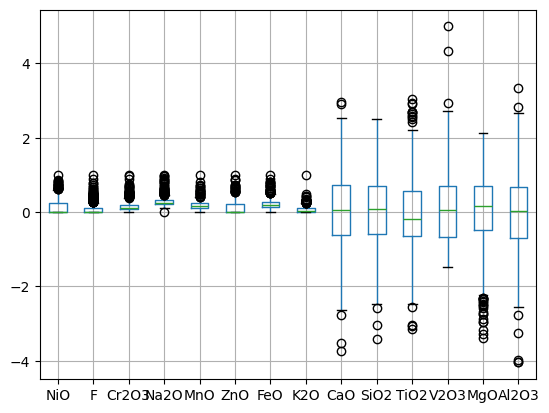

In [ ]:
epma2.boxplot(column=['NiO', 'F', 'Cr2O3', 'Na2O', 'MnO', 'ZnO', 'FeO', 'K2O', 'CaO', 'SiO2',
       'TiO2', 'V2O3', 'MgO', 'Al2O3'])


**9. Shuffle the Dataset**

Purpose: Ensure data is randomized to avoid biases from the original order.

In [ ]:
from sklearn.utils import shuffle
epma2 = shuffle(epma2, random_state=42)


**10. Final Dataset Review**

Verify Dimensions: Ensure the dataset has the expected number of rows and columns.
Preview Data: Check the first few rows to confirm data integrity.

In [ ]:
epma2.shape

(418, 15)

In [ ]:
epma2.head()

,NiO,F,Cr2O3,Na2O,MnO,ZnO,FeO,K2O,CaO,SiO2,TiO2,V2O3,MgO,Al2O3,T
321,0.000000,0.098655,0.087694,0.435239,0.315789,0.000000,0.426921,0.000000,-0.086134,-0.595574,-0.130038,1.020490,-1.177918,0.593104,2.0
324,0.440476,0.040359,0.117397,0.375729,0.210526,0.000000,0.387392,0.000000,-0.614105,-0.442478,-0.325993,0.225537,-0.904376,0.375515,2.0
388,0.333333,0.053812,0.239038,0.249708,0.035088,0.102564,0.158591,0.050847,0.903376,-0.501964,0.472235,0.478476,0.231962,0.674571,2.0
56,0.000000,0.170404,0.147100,0.289965,0.180702,0.461538,0.148151,0.000000,-0.087882,-0.190238,0.881435,1.598638,0.104901,0.709633,3.0
153,0.261905,0.000000,0.578501,0.283547,0.075439,0.000000,0.098821,0.042373,-0.332637,0.514373,-0.470077,-0.677820,0.629792,-0.444826,1.0


In [ ]:
'''
import pandas as pd


# Save to Excel
file_path = "/content/drive/MyDrive/a dissertation methodoloy/preprocessed1.xlsx"
epma2.to_excel(file_path, index=False, engine='openpyxl')  # engine='openpyxl' is preferred for xlsx files

print(f"DataFrame saved successfully to {file_path}")

'''


'\nimport pandas as pd\n\n\n# Save to Excel\nfile_path = "/content/drive/MyDrive/a dissertation methodoloy/preprocessed1.xlsx"\nepma2.to_excel(file_path, index=False, engine=\'openpyxl\')  # engine=\'openpyxl\' is preferred for xlsx files\n\nprint(f"DataFrame saved successfully to {file_path}")\n\n'

#**splitting the data**

In [ ]:
#for splitting the dataframes

from sklearn.model_selection import train_test_split, StratifiedKFold

# for calling the models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

#for calling the model performance metrics
from sklearn.metrics import accuracy_score


In [ ]:
# Defining the dataframe into X features and y target label

X = epma2.drop(columns=['T'])
y = epma2['T']


In [ ]:
#for splitting the dataframes

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,

                                                    stratify=y, #applying stratified splitting to ensure proportional representation of target classes in training and test sets.

                                                    random_state=42)


#**Applying logistic regression to it with k fold cross validation**

In [ ]:
# for calling the models

from sklearn.linear_model import LogisticRegression

#for calling the model performance metrics
from sklearn.metrics import accuracy_score

# defining the function train_and_evaluate

# it takes the argument X_train_fold, y_train_fold, X_val_fold and y_val_fold

def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    """
    it Train and evaluate the model on a single fold using Logistic Regression.
    """
    # Train the model

    model = LogisticRegression(random_state=42, max_iter=1000)  # Increased max_iter for convergence

    model.fit(X_train_fold, y_train_fold)

    # Validate the model

    y_val_pred = model.predict(X_val_fold) # prediction on X_val_fold

    accuracy = accuracy_score(y_val_fold, y_val_pred) # where y_val_pred = model.predict(X_val_fold)

    return accuracy

###########################################################################################################################

from sklearn.model_selection import StratifiedKFold

fold_accuracies = []

fold_models = []  # Store models for each fold

# Define Stratified K-Fold as kf where,

kf = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=42)


# Loop through the folds
for fold, (train_index, val_index) in enumerate( kf.split( X_train, y_train ) ):

    # Split the data into training and validation subsets

    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]

    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Call the training function

    accuracy = train_and_evaluate(X_train_fold,
                                  y_train_fold,
                                  X_val_fold,
                                  y_val_fold)

    fold_accuracies.append(accuracy)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")


# Calculate the average accuracy across all folds

avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)

print(f"Average CV Accuracy: {avg_accuracy:.4f}")




Fold 1 Accuracy: 0.7015
Fold 2 Accuracy: 0.6866
Fold 3 Accuracy: 0.5522
Fold 4 Accuracy: 0.8209
Fold 5 Accuracy: 0.6970
Average CV Accuracy: 0.6916


Average CV Accuracy: 0.6916


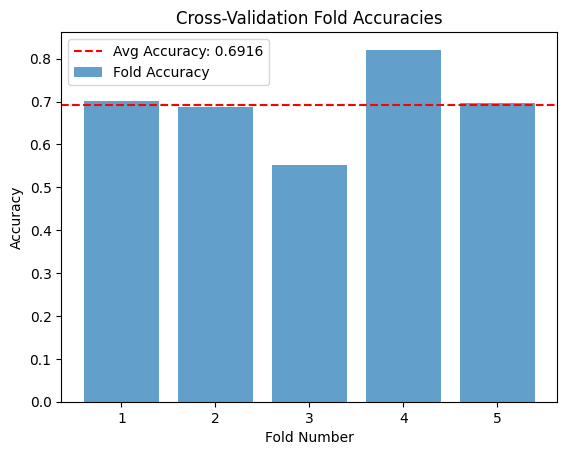

In [ ]:
import matplotlib.pyplot as plt

# Calculate the average accuracy across all folds

avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)

print(f"Average CV Accuracy: {avg_accuracy:.4f}")


# Visualization

folds = list(range(1,
                   len(fold_accuracies) + 1))

# Bar plot for individual fold accuracies

plt.bar(folds,
        fold_accuracies,
        alpha=0.7,
        label="Fold Accuracy")

plt.axhline(avg_accuracy,

            color= 'red',

            linestyle= '--',

            label= f"Avg Accuracy: {avg_accuracy:.4f}" )

# Add labels and title

plt.xlabel("Fold Number")

plt.ylabel("Accuracy")

plt.title("Cross-Validation Fold Accuracies")

plt.xticks(folds)

plt.legend()

# Show plot

plt.show()


In [ ]:
# Get predictions for Fold 3
y_val_pred = model.predict(X_val_fold)

# Identify mismatches
mismatches = X_val_fold[y_val_pred != y_val_fold]
mismatched_labels = y_val_fold[y_val_pred != y_val_fold]

# Display mismatched rows
print("Mislabeled samples in Fold 3:")
print(mismatches)
print("True labels:", mismatched_labels)
print("Predicted labels:", y_val_pred[y_val_pred != y_val_fold])


# Use the model for Fold 3 to check for mislabeling
fold_3_model = fold_models[2]  # Model from Fold 3 (index starts at 0)
y_val_pred = fold_3_model.predict(X_val_fold)

# Identify mismatches in Fold 3
mismatches = X_val_fold[y_val_pred != y_val_fold]
mismatched_labels = y_val_fold[y_val_pred != y_val_fold]

print("Mislabeled samples in Fold 3:")
print(mismatches)
print("True labels:", mismatched_labels)
print("Predicted labels:", y_val_pred[y_val_pred != y_val_fold])


Mislabeled samples in Fold 3:
          NiO         F     Cr2O3      Na2O       MnO       ZnO       FeO  \
62   0.059524  0.000000  0.067893  0.134772  0.259649  0.897436  0.122171   
359  0.167464  0.000000  0.021856  0.263918  0.260833  0.000000  0.324215   
233  0.000000  0.614350  0.226308  0.251459  0.061404  0.000000  0.158750   
230  0.000000  0.327354  0.130127  0.179113  0.168421  0.115385  0.256933   
400  0.297619  0.233184  0.596888  0.230455  0.040351  0.000000  0.058256   
328  0.238095  0.282511  0.405941  0.233956  0.045614  0.570513  0.024785   
311  0.238095  0.000000  0.107496  0.292299  0.147368  0.000000  0.234778   
170  0.107143  0.125561  0.407355  0.236873  0.056140  0.153846  0.119142   
6    0.000000  0.000000  0.125884  0.000000  0.091228  0.525641  0.565429   
317  0.000000  0.000000  0.015559  0.303384  0.161404  0.000000  0.255419   
5    0.428571  0.000000  0.206506  0.277130  0.228070  0.096154  0.147673   
33   0.000000  0.000000  0.091938  0.382147  0

In [ ]:
'''
def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    """
    Train and evaluate the model on a single fold using Logistic Regression.
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score

    # Train the model
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_fold, y_train_fold)

    # Validate the model
    y_val_pred = model.predict(X_val_fold)
    accuracy = accuracy_score(y_val_fold, y_val_pred)

    return accuracy, model

fold_accuracies = []
fold_models = []  # Store models for each fold

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train and evaluate
    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)
    fold_models.append(model)  # Save the model for later use

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
'''
# Use the model for Fold 3 to check for mislabeling
fold_3_model = fold_models[2]  # Model from Fold 3 (index starts at 0)
y_val_pred = fold_3_model.predict(X_val_fold)

# Identify mismatches in Fold 3
mismatches = X_val_fold[y_val_pred != y_val_fold]
mismatched_labels = y_val_fold[y_val_pred != y_val_fold]

print("Mislabeled samples in Fold 3:")
print(mismatches)
print("True labels:", mismatched_labels)
print("Predicted labels:", y_val_pred[y_val_pred != y_val_fold])


Mislabeled samples in Fold 3:
          NiO         F     Cr2O3      Na2O       MnO       ZnO       FeO  \
62   0.059524  0.000000  0.067893  0.134772  0.259649  0.897436  0.122171   
359  0.167464  0.000000  0.021856  0.263918  0.260833  0.000000  0.324215   
233  0.000000  0.614350  0.226308  0.251459  0.061404  0.000000  0.158750   
230  0.000000  0.327354  0.130127  0.179113  0.168421  0.115385  0.256933   
400  0.297619  0.233184  0.596888  0.230455  0.040351  0.000000  0.058256   
328  0.238095  0.282511  0.405941  0.233956  0.045614  0.570513  0.024785   
311  0.238095  0.000000  0.107496  0.292299  0.147368  0.000000  0.234778   
170  0.107143  0.125561  0.407355  0.236873  0.056140  0.153846  0.119142   
70   0.000000  0.000000  0.444884  0.310742  0.172693  0.000000  0.166554   
5    0.428571  0.000000  0.206506  0.277130  0.228070  0.096154  0.147673   
33   0.000000  0.000000  0.091938  0.382147  0.235088  0.000000  0.391935   
179  0.000000  0.426009  0.104668  0.395566  0

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import numpy as np

# Placeholder for metrics
fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1_scores = []
fold_confusion_matrices = []
fold_models = []

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train and evaluate
    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)
    fold_models.append(model)

    # Validate and calculate additional metrics
    y_val_pred = model.predict(X_val_fold)

    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1_scores.append(f1)
    fold_confusion_matrices.append(confusion)

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  Confusion Matrix:\n{confusion}\n")

# Calculate average metrics
avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)
avg_precision = sum(fold_precisions) / len(fold_precisions)
avg_recall = sum(fold_recalls) / len(fold_recalls)
avg_f1_score = sum(fold_f1_scores) / len(fold_f1_scores)

print("Average Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")



Fold 1 Metrics:
  Accuracy: 0.7015
  Precision: 0.6850
  Recall: 0.7015
  F1-Score: 0.6840
  Confusion Matrix:
[[18  4  3]
 [ 4 26  0]
 [ 7  2  3]]

Fold 2 Metrics:
  Accuracy: 0.6866
  Precision: 0.6582
  Recall: 0.6866
  F1-Score: 0.6639
  Confusion Matrix:
[[19  6  1]
 [ 3 25  2]
 [ 6  3  2]]

Fold 3 Metrics:
  Accuracy: 0.5522
  Precision: 0.5082
  Recall: 0.5522
  F1-Score: 0.5191
  Confusion Matrix:
[[13 11  2]
 [ 5 23  1]
 [ 9  2  1]]

Fold 4 Metrics:
  Accuracy: 0.8209
  Precision: 0.8224
  Recall: 0.8209
  F1-Score: 0.8073
  Confusion Matrix:
[[22  3  1]
 [ 1 28  0]
 [ 6  1  5]]

Fold 5 Metrics:
  Accuracy: 0.6970
  Precision: 0.7047
  Recall: 0.6970
  F1-Score: 0.6750
  Confusion Matrix:
[[20  5  0]
 [ 5 23  1]
 [ 5  4  3]]

Average Metrics Across All Folds:
  Accuracy: 0.6916
  Precision: 0.6757
  Recall: 0.6916
  F1-Score: 0.6699


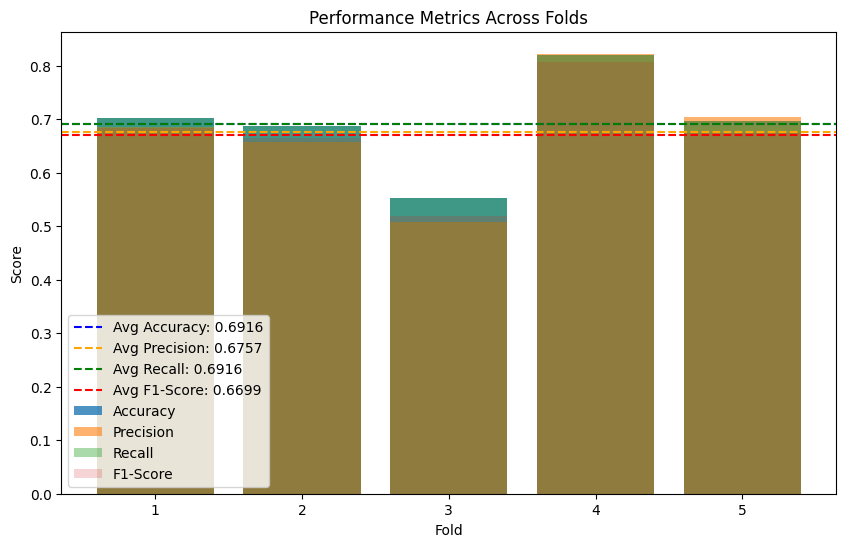

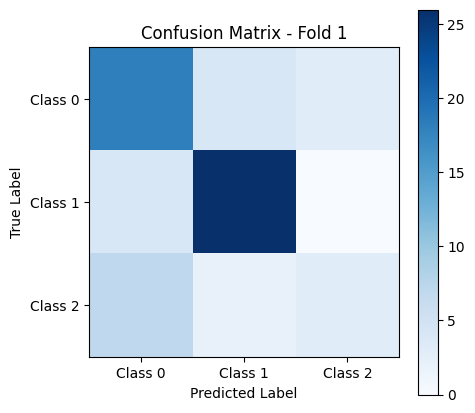

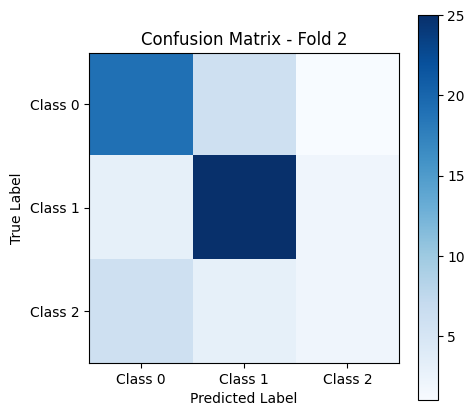

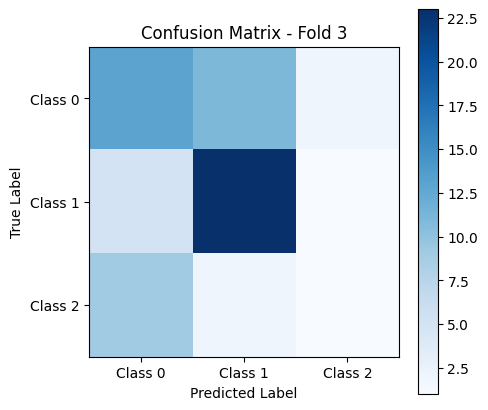

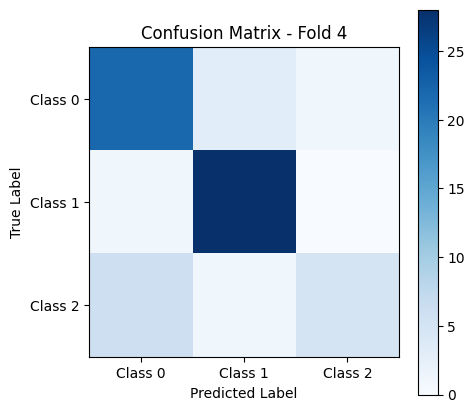

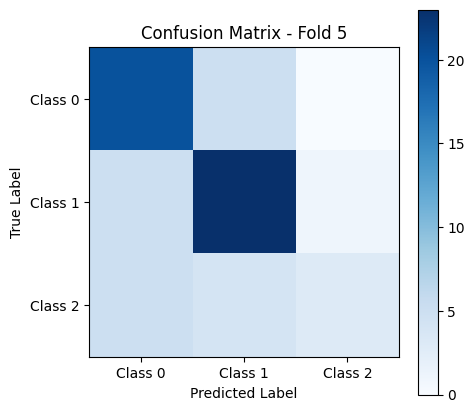

In [ ]:
# Plotting metrics for each fold
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))

# Bar chart for Accuracy, Precision, Recall, and F1-Score
plt.bar(folds, fold_accuracies, alpha=0.8, label='Accuracy')
plt.bar(folds, fold_precisions, alpha=0.6, label='Precision')
plt.bar(folds, fold_recalls, alpha=0.4, label='Recall')
plt.bar(folds, fold_f1_scores, alpha=0.2, label='F1-Score')

plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.axhline(avg_precision, color='orange', linestyle='--', label=f'Avg Precision: {avg_precision:.4f}')
plt.axhline(avg_recall, color='green', linestyle='--', label=f'Avg Recall: {avg_recall:.4f}')
plt.axhline(avg_f1_score, color='red', linestyle='--', label=f'Avg F1-Score: {avg_f1_score:.4f}')

# Labels and legend
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Performance Metrics Across Folds')
plt.xticks(folds)
plt.legend()
plt.show()

for fold, confusion in enumerate(fold_confusion_matrices, start=1):
    plt.figure(figsize=(5, 5))
    plt.imshow(confusion, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.colorbar()

    # Dynamically set ticks and labels based on the number of classes
    classes = range(confusion.shape[0])
    plt.xticks(classes, labels=[f'Class {i}' for i in classes])
    plt.yticks(classes, labels=[f'Class {i}' for i in classes])

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

#**applying random forrest classifier**

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
X = epma2.drop(columns=['T'])
y = epma2['T']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,

                                                    stratify=y, #applying stratified splitting to ensure proportional representation of target classes in training and test sets.

                                                    random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    """
    Train and evaluate the model on a single fold using RFC.
    """
    # Train the model
    model = RandomForestClassifier(random_state=42)  # Increased max_iter for convergence
    model.fit(X_train_fold, y_train_fold)

    # Validate the model
    y_val_pred = model.predict(X_val_fold)
    accuracy = accuracy_score(y_val_fold, y_val_pred)

    return accuracy



In [ ]:
from sklearn.model_selection import StratifiedKFold

fold_accuracies = []


fold_models = []  # Store models for each fold

# Define Stratified K-Fold
kf = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)

# Loop through the folds

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):

    # Split the data into training and validation subsets

    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]

    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Call the training function

    accuracy = train_and_evaluate(X_train_fold,
                                  y_train_fold,
                                  X_val_fold,
                                  y_val_fold)

    fold_accuracies.append(accuracy)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")

# Calculate the average accuracy across all folds
avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)
print(f"Average CV Accuracy: {avg_accuracy:.4f}")


Fold 1 Accuracy: 0.7391
Fold 2 Accuracy: 0.7391
Fold 3 Accuracy: 0.6522
Fold 4 Accuracy: 0.8696
Fold 5 Accuracy: 0.8182
Fold 6 Accuracy: 0.5909
Fold 7 Accuracy: 0.7727
Fold 8 Accuracy: 0.7273
Fold 9 Accuracy: 0.6364
Fold 10 Accuracy: 0.9091
Fold 11 Accuracy: 0.6818
Fold 12 Accuracy: 0.7727
Fold 13 Accuracy: 0.7727
Fold 14 Accuracy: 0.6818
Fold 15 Accuracy: 0.9091
Average CV Accuracy: 0.7515


Average CV Accuracy: 0.7515


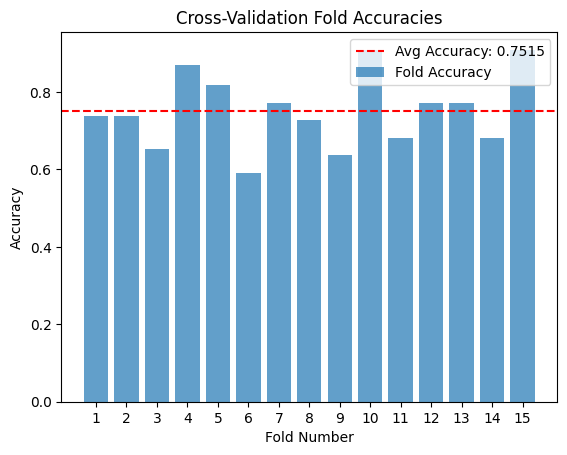

In [ ]:
import matplotlib.pyplot as plt

# Calculate the average accuracy across all folds
avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)
print(f"Average CV Accuracy: {avg_accuracy:.4f}")


# Visualization
folds = list(range(1, len(fold_accuracies) + 1))

# Bar plot for individual fold accuracies
plt.bar(folds, fold_accuracies, alpha=0.7, label="Fold Accuracy")
plt.axhline(avg_accuracy, color='red', linestyle='--', label=f"Avg Accuracy: {avg_accuracy:.4f}")

# Add labels and title
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Fold Accuracies")
plt.xticks(folds)
plt.legend()

# Show plot
plt.show()

In [ ]:
def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    """
    Train and evaluate the model on a single fold using Logistic Regression.
    """
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score

    # Train the model
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_fold, y_train_fold)

    # Validate the model
    y_val_pred = model.predict(X_val_fold)
    accuracy = accuracy_score(y_val_fold, y_val_pred)

    return accuracy, model


fold_accuracies = []
fold_models = []  # Store models for each fold

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):

    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]

    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train and evaluate

    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)

    fold_accuracies.append(accuracy)

    fold_models.append(model)  # Save the model for later use

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")

# Calculate the average accuracy across all folds
avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)
print(f"Average CV Accuracy: {avg_accuracy:.4f}")


# Use the model for Fold 6 to check for mislabeling
fold_6_model = fold_models[7]  # Model from Fold 3 (index starts at 0)
y_val_pred = fold_6_model.predict(X_val_fold)

# Identify mismatches in Fold 6
mismatches = X_val_fold[y_val_pred != y_val_fold]
mismatched_labels = y_val_fold[y_val_pred != y_val_fold]

print("Mislabeled samples in Fold 6:")
print(mismatches)
print("True labels:", mismatched_labels)
print("Predicted labels:", y_val_pred[y_val_pred != y_val_fold])


Fold 1 Accuracy: 0.7391
Fold 2 Accuracy: 0.7391
Fold 3 Accuracy: 0.6522
Fold 4 Accuracy: 0.8696
Fold 5 Accuracy: 0.8182
Fold 6 Accuracy: 0.5909
Fold 7 Accuracy: 0.7727
Fold 8 Accuracy: 0.7273
Fold 9 Accuracy: 0.6364
Fold 10 Accuracy: 0.9091
Fold 11 Accuracy: 0.6818
Fold 12 Accuracy: 0.7727
Fold 13 Accuracy: 0.7727
Fold 14 Accuracy: 0.6818
Fold 15 Accuracy: 0.9091
Average CV Accuracy: 0.7515
Mislabeled samples in Fold 6:
Empty DataFrame
Columns: [NiO, F, Cr2O3, Na2O, MnO, ZnO, FeO, K2O, CaO, SiO2, TiO2, V2O3, MgO, Al2O3]
Index: []
True labels: Series([], Name: T, dtype: float64)
Predicted labels: []


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import numpy as np

# Placeholder for metrics
fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1_scores = []
fold_confusion_matrices = []
fold_models = []

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Train and evaluate
    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)
    fold_models.append(model)

    # Validate and calculate additional metrics
    y_val_pred = model.predict(X_val_fold)

    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1_scores.append(f1)
    fold_confusion_matrices.append(confusion)

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  Confusion Matrix:\n{confusion}\n")

# Calculate average metrics
avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)
avg_precision = sum(fold_precisions) / len(fold_precisions)
avg_recall = sum(fold_recalls) / len(fold_recalls)
avg_f1_score = sum(fold_f1_scores) / len(fold_f1_scores)

print("Average Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")





Fold 1 Metrics:
  Accuracy: 0.6765
  Precision: 0.6527
  Recall: 0.6765
  F1-Score: 0.6466
  Confusion Matrix:
[[ 9  3  1]
 [ 2 13  0]
 [ 3  2  1]]

Fold 2 Metrics:
  Accuracy: 0.7647
  Precision: 0.7585
  Recall: 0.7647
  F1-Score: 0.7604
  Confusion Matrix:
[[10  1  2]
 [ 2 13  0]
 [ 1  2  3]]

Fold 3 Metrics:
  Accuracy: 0.8235
  Precision: 0.8431
  Recall: 0.8235
  F1-Score: 0.8155
  Confusion Matrix:
[[11  2  0]
 [ 1 14  0]
 [ 1  2  3]]

Fold 4 Metrics:
  Accuracy: 0.5882
  Precision: 0.5790
  Recall: 0.5882
  F1-Score: 0.5661
  Confusion Matrix:
[[ 9  4  0]
 [ 4 10  1]
 [ 3  2  1]]

Fold 5 Metrics:
  Accuracy: 0.8485
  Precision: 0.8615
  Recall: 0.8485
  F1-Score: 0.8471
  Confusion Matrix:
[[11  1  0]
 [ 2 13  0]
 [ 1  1  4]]

Fold 6 Metrics:
  Accuracy: 0.6364
  Precision: 0.6576
  Recall: 0.6364
  F1-Score: 0.6071
  Confusion Matrix:
[[ 5  7  0]
 [ 0 14  1]
 [ 2  2  2]]

Fold 7 Metrics:
  Accuracy: 0.8485
  Precision: 0.8585
  Recall: 0.8485
  F1-Score: 0.8450
  Confusion Mat

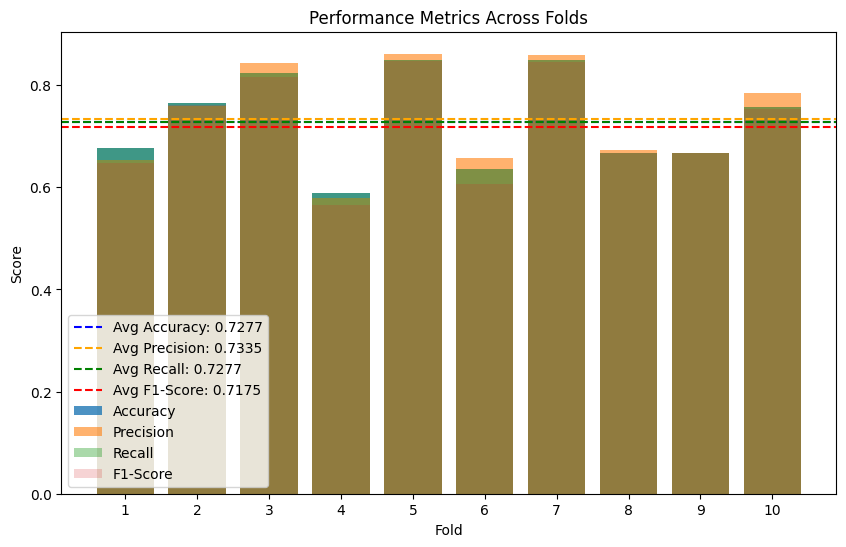

In [ ]:
# Plotting metrics for each fold
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))

# Bar chart for Accuracy, Precision, Recall, and F1-Score
plt.bar(folds, fold_accuracies, alpha=0.8, label='Accuracy')
plt.bar(folds, fold_precisions, alpha=0.6, label='Precision')
plt.bar(folds, fold_recalls, alpha=0.4, label='Recall')
plt.bar(folds, fold_f1_scores, alpha=0.2, label='F1-Score')

plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.axhline(avg_precision, color='orange', linestyle='--', label=f'Avg Precision: {avg_precision:.4f}')
plt.axhline(avg_recall, color='green', linestyle='--', label=f'Avg Recall: {avg_recall:.4f}')
plt.axhline(avg_f1_score, color='red', linestyle='--', label=f'Avg F1-Score: {avg_f1_score:.4f}')

# Labels and legend
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Performance Metrics Across Folds')
plt.xticks(folds)
plt.legend()
plt.show()



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fold 1 Metrics:
  Accuracy: 0.7391
  Precision: 0.6084
  Recall: 0.7391
  F1-Score: 0.6664
Fold 2 Metrics:
  Accuracy: 0.7391
  Precision: 0.7484
  Recall: 0.7391
  F1-Score: 0.7362
Fold 3 Metrics:
  Accuracy: 0.6522
  Precision: 0.6504
  Recall: 0.6522
  F1-Score: 0.6458
Fold 4 Metrics:
  Accuracy: 0.8696
  Precision: 0.8854
  Recall: 0.8696
  F1-Score: 0.8594
Fold 5 Metrics:
  Accuracy: 0.8182
  Precision: 0.8162
  Recall: 0.8182
  F1-Score: 0.8099
Fold 6 Metrics:
  Accuracy: 0.5909
  Precision: 0.5931
  Recall: 0.5909
  F1-Score: 0.5714
Fold 7 Metrics:
  Accuracy: 0.7727
  Precision: 0.7961
  Recall: 0.7727
  F1-Score: 0.7675
Fold 8 Metrics:
  Accuracy: 0.7273
  Precision: 0.7273
  Recall: 0.7273
  F1-Score: 0.7273
Fold 9 Metrics:
  Accuracy: 0.6364
  Precision: 0.7219
  Recall: 0.6364
  F1-Score: 0.5912
Fold 10 Metrics:
  Accuracy: 0.9091
  Precision: 0.9242
  Recall: 0.9091
  F1-Score: 0.8981
Fold 11 Metrics:
  Accuracy: 0.6818
  Precision: 0.7020
  Recall: 0.6818
  F1-Score: 0.68

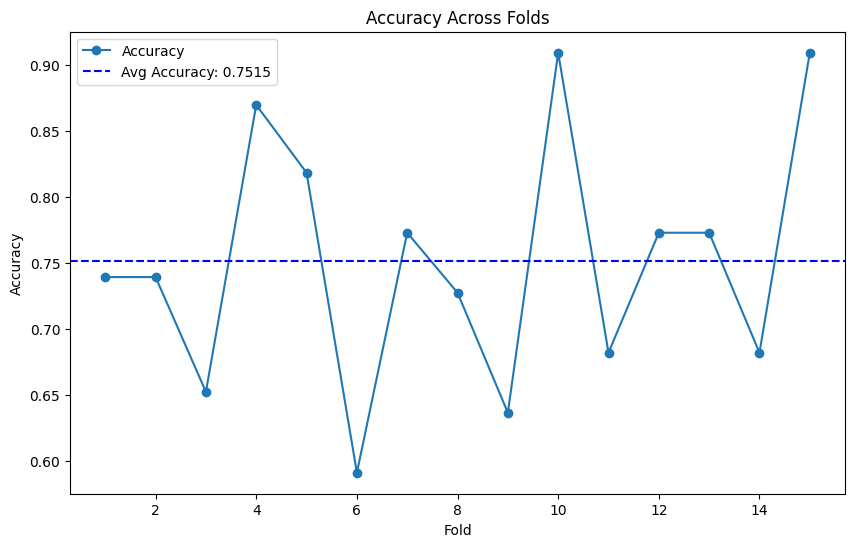

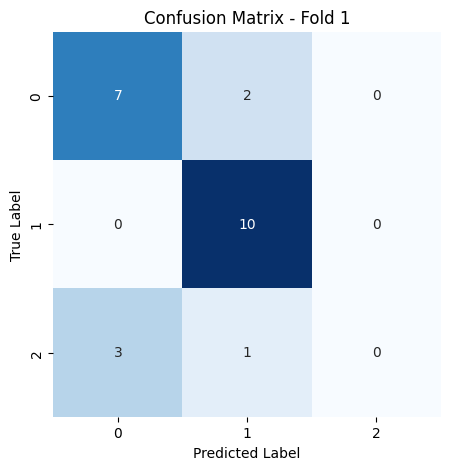

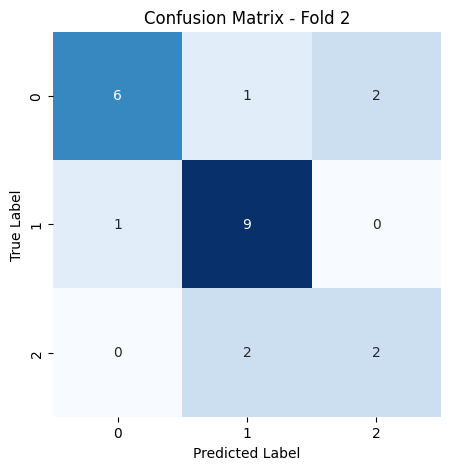

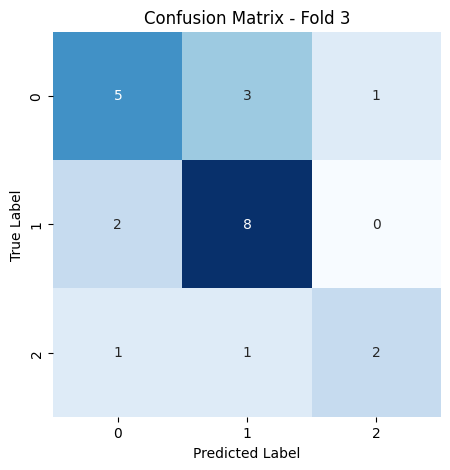

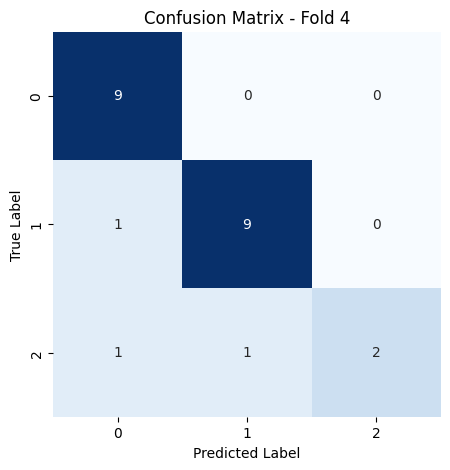

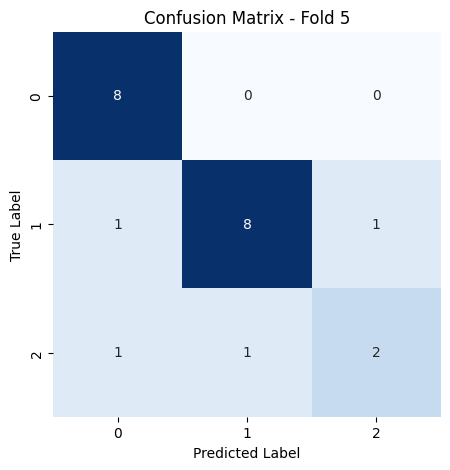

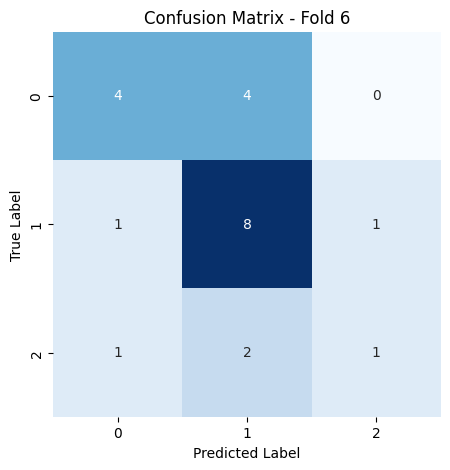

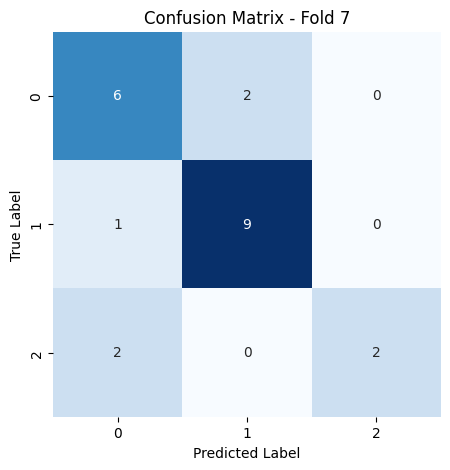

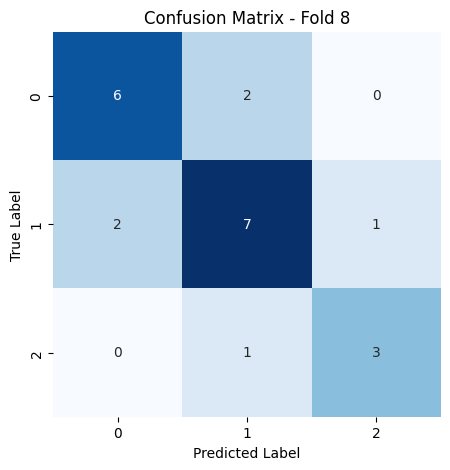

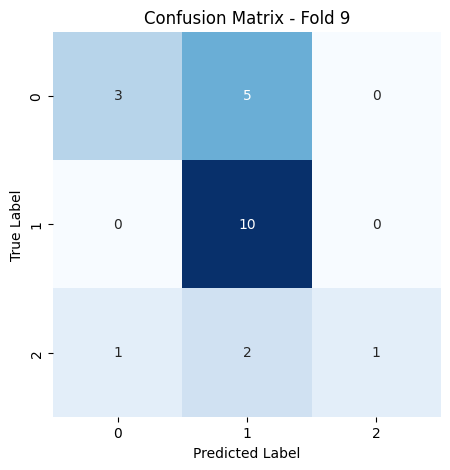

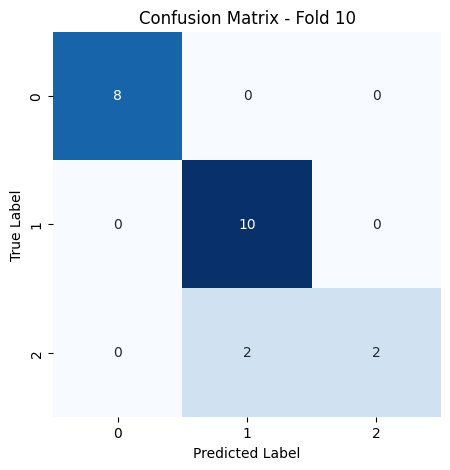

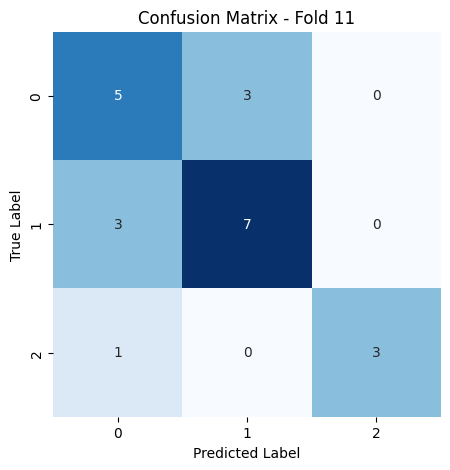

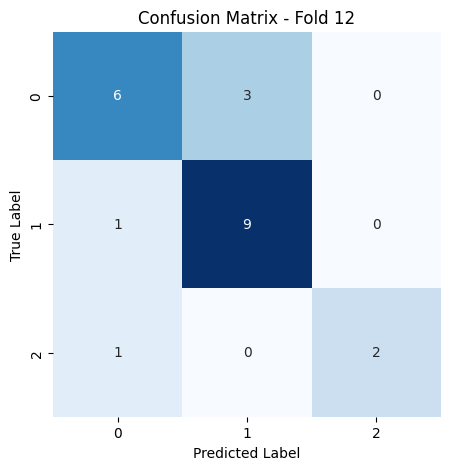

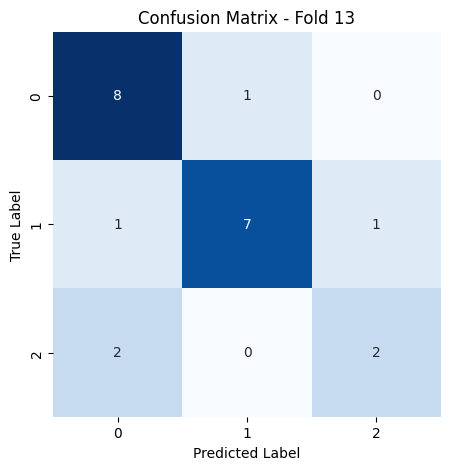

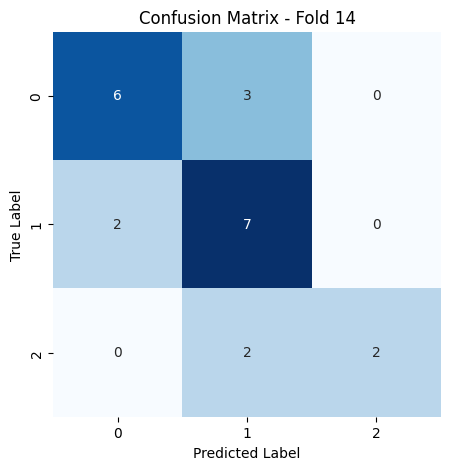

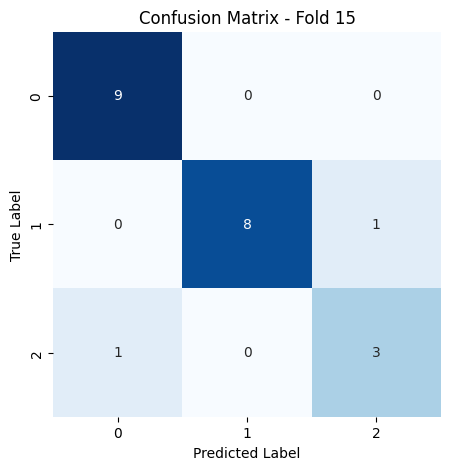


Test Set Metrics:
  Accuracy: 0.7143
  Precision: 0.7175
  Recall: 0.7143
  F1-Score: 0.7048


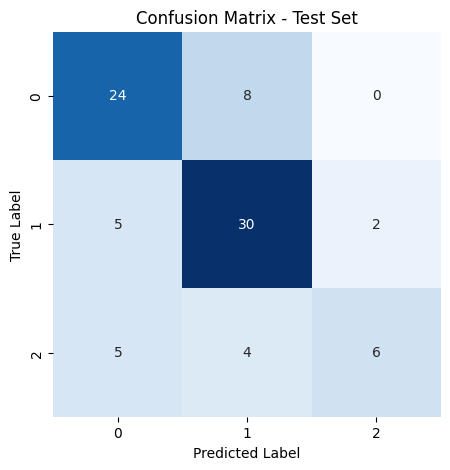

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load dataset (assuming epma2 is already loaded as a DataFrame)
X = epma2.drop(columns=['T'])
y = epma2['T']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Function to train and evaluate the model
def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    """Train and evaluate Random Forest Classifier."""
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_fold, y_train_fold)
    y_val_pred = model.predict(X_val_fold)
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    return accuracy, model

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)

fold_accuracies = []
fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'confusion_matrices': []
}
best_model = None
best_accuracy = 0

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)

    # Validate additional metrics
    y_val_pred = model.predict(X_val_fold)
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_metrics['precision'].append(precision)
    fold_metrics['recall'].append(recall)
    fold_metrics['f1_score'].append(f1)
    fold_metrics['confusion_matrices'].append(confusion)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

# Average Metrics
avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_metrics['precision'])
avg_recall = np.mean(fold_metrics['recall'])
avg_f1_score = np.mean(fold_metrics['f1_score'])

print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")

# Save the best model
joblib.dump(best_model, 'best_random_forest_model.pkl')

# Plot Metrics
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))
plt.plot(folds, fold_accuracies, marker='o', label='Accuracy')
plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across Folds')
plt.legend()
plt.show()

# Confusion Matrix Visualization
for fold, confusion in enumerate(fold_metrics['confusion_matrices'], start=1):
    plt.figure(figsize=(5, 5))
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Test Set Evaluation
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")

# Test Confusion Matrix
plt.figure(figsize=(5, 5))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


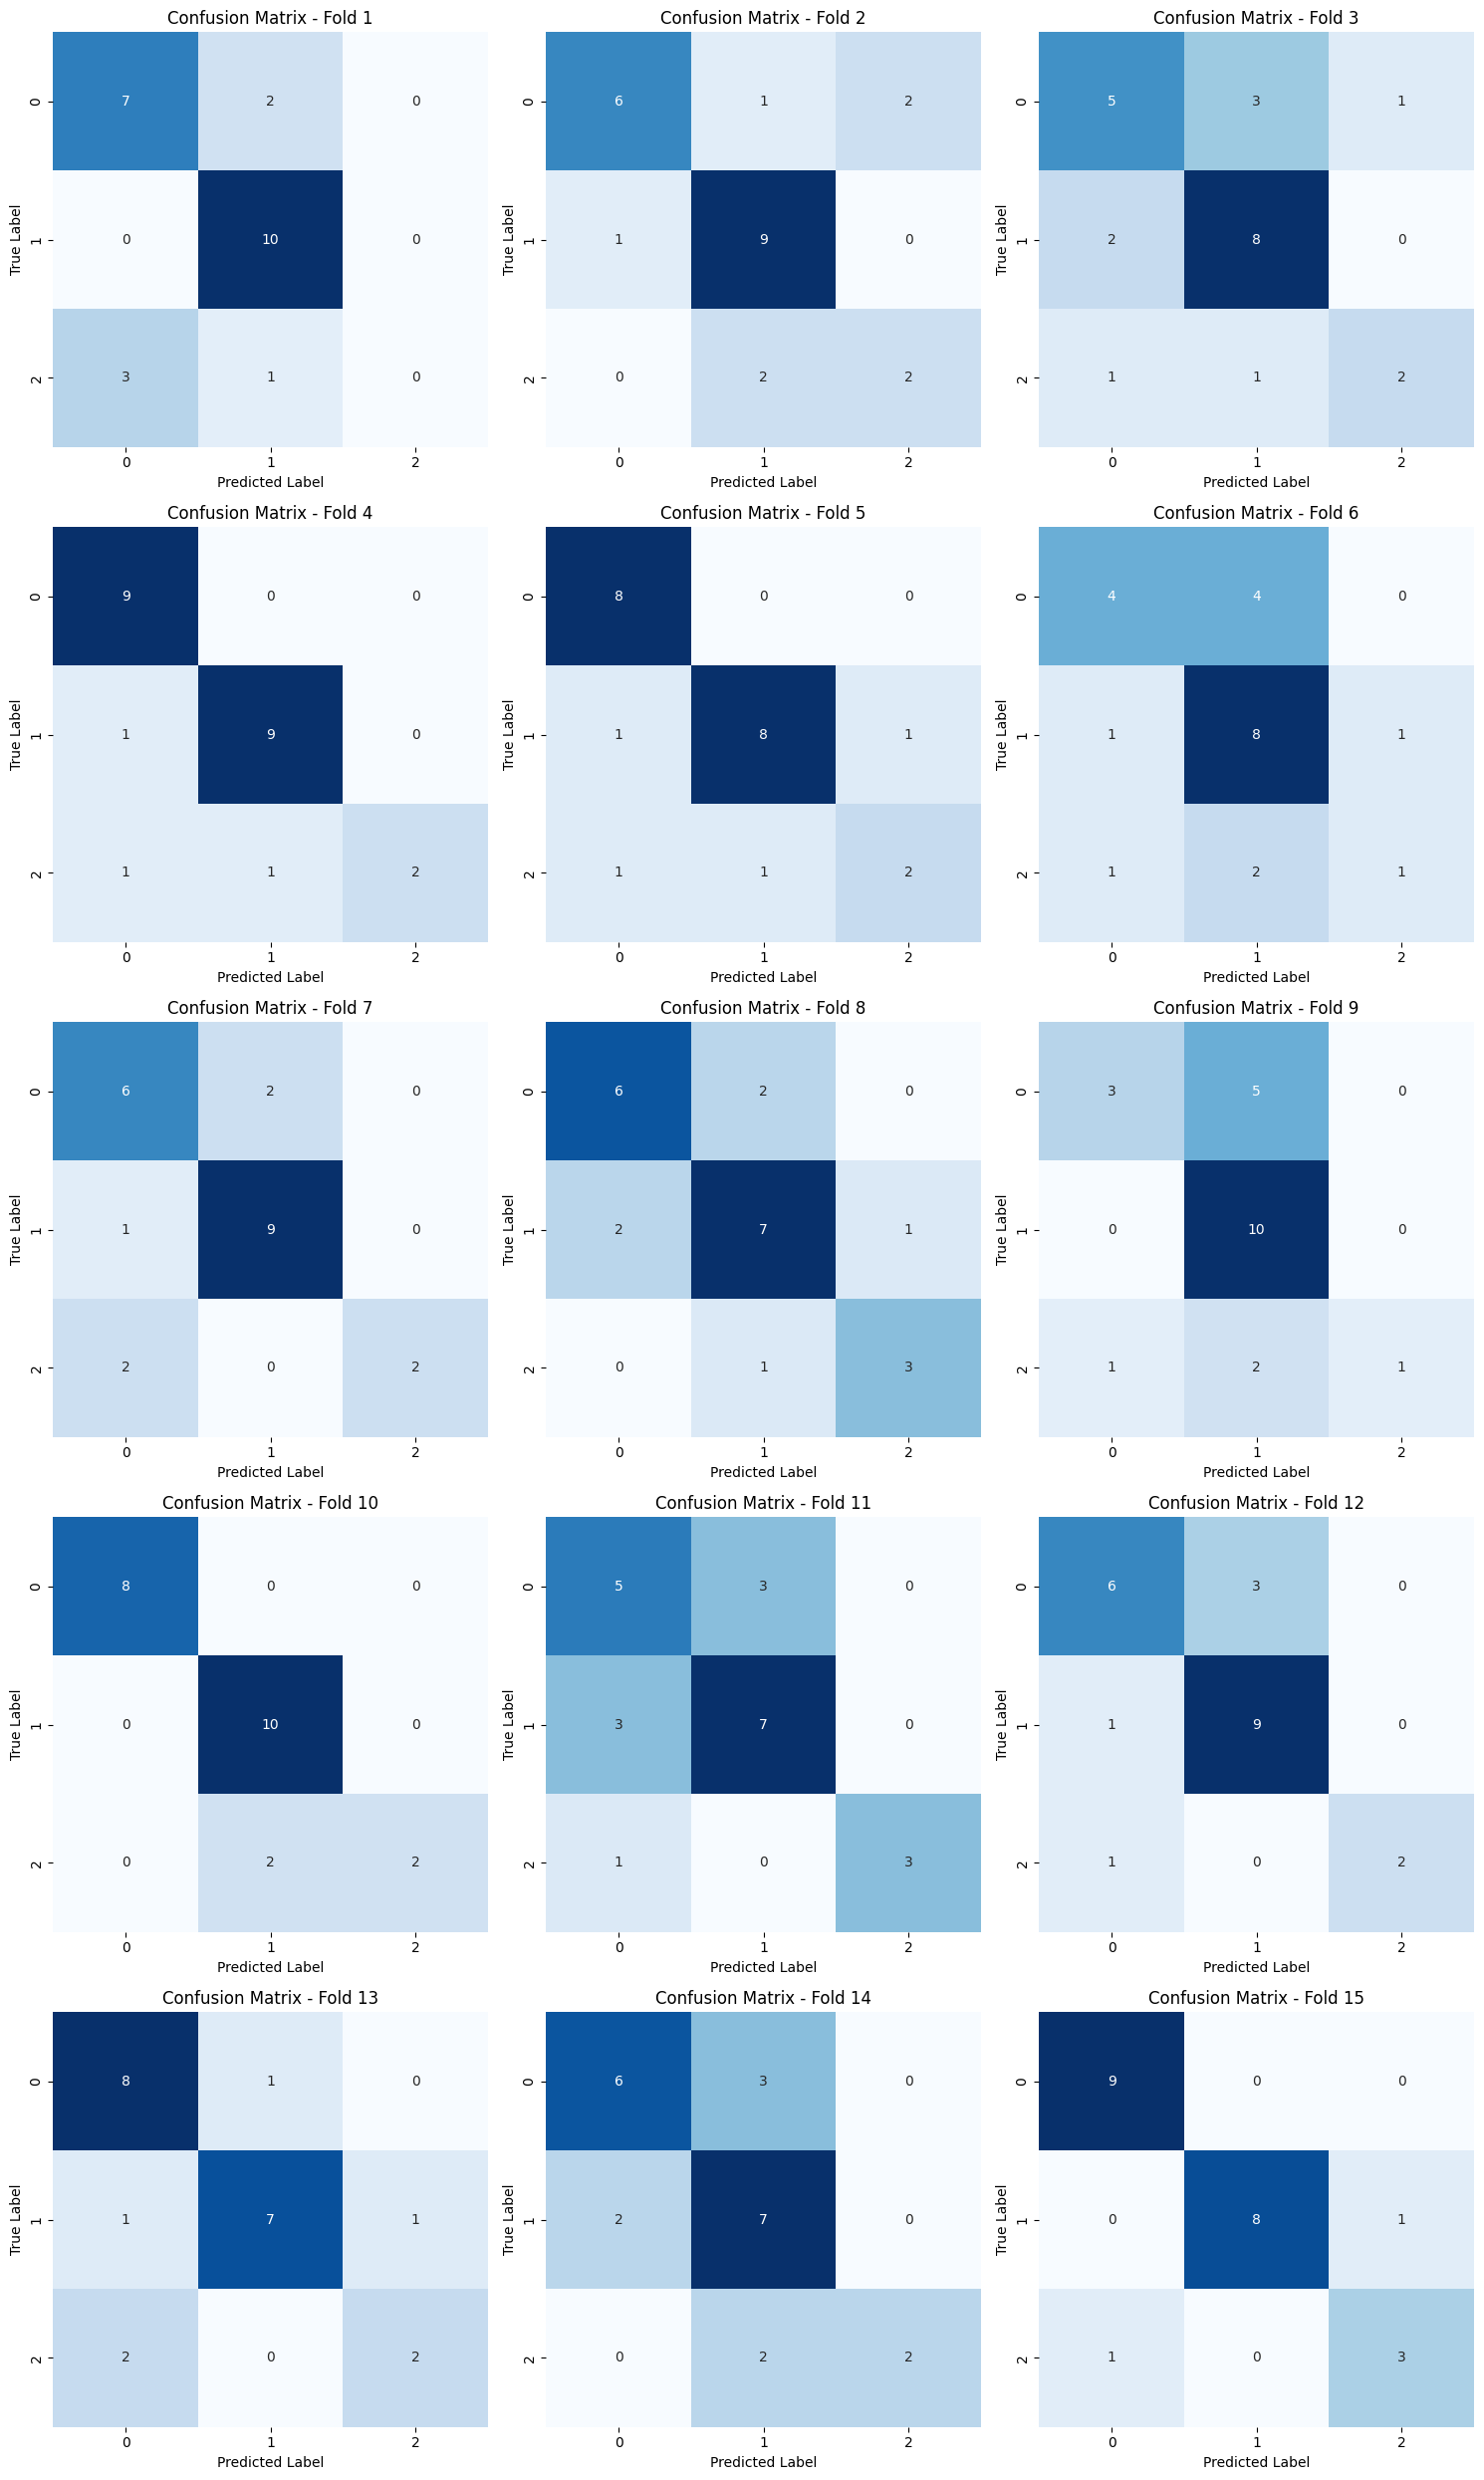

In [ ]:
# Confusion Matrix Subplots for Cross-Validation Folds
num_folds = len(fold_metrics['confusion_matrices'])
cols = 3  # Number of columns in the subplot grid
rows = (num_folds // cols) + (num_folds % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  # Flatten the axes array for easy indexing

for idx, confusion in enumerate(fold_metrics['confusion_matrices']):
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - Fold {idx + 1}')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

# Remove unused subplots if any
for idx in range(len(fold_metrics['confusion_matrices']), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


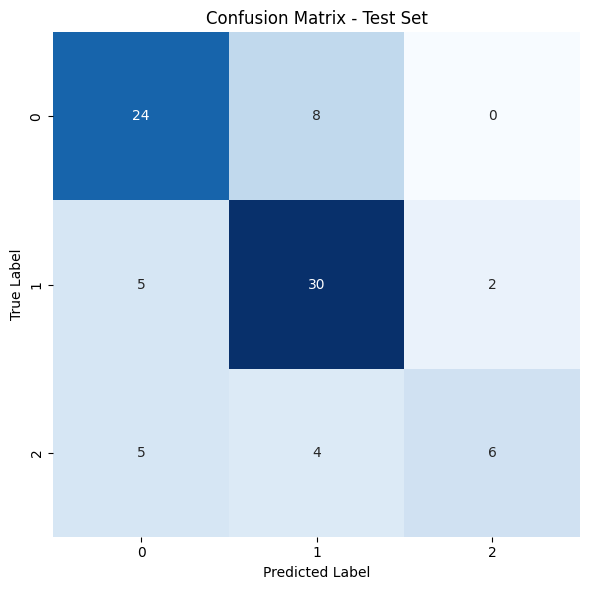

In [ ]:
# Add Test Set Confusion Matrix
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes)
axes.set_title('Confusion Matrix - Test Set')
axes.set_xlabel('Predicted Label')
axes.set_ylabel('True Label')
plt.tight_layout()
plt.show()


#**ensemble models**

**Parameters for Logistic Regression in scikit-learn**

logistic_regression_params = {

    'penalty': [
        'l1',         # L1 regularization (Lasso) for sparsity in coefficients
        'l2',         # L2 regularization (Ridge) to prevent overfitting
        'elasticnet', # Combination of L1 and L2 regularization
        'none'        # No regularization
    ],
    'dual': [
        True,  # Use dual formulation (only for small datasets with liblinear solver)
        False  # Default, solve the primal problem
    ],
    'tol': 'Tolerance for stopping criteria (e.g., 1e-4 as default)',
    'C': 'Inverse of regularization strength (float, default=1.0). Smaller values mean stronger regularization.',
    'fit_intercept': [
        True,  # Fit a bias or intercept (default)
        False  # Do not fit an intercept
    ],
    'class_weight': [
        'balanced', # Adjust weights inversely proportional to class frequencies
        None,       # No class weighting (default)
        'dict'      # Custom dictionary of class weights
    ],
    'solver': [
        'newton-cg', # Newton’s method
        'lbfgs',     # Limited-memory Broyden–Fletcher–Goldfarb–Shanno
        'liblinear', # Coordinate descent (small datasets)
        'sag',       # Stochastic Average Gradient
        'saga'       # Variant of SAG supporting L1, L2, elastic-net
    ],
    'max_iter': 'Maximum number of iterations for the solver to converge (int, default=100)',
    'multi_class': [
        'auto',        # Default: One-vs-Rest or Multinomial based on solver
        'ovr',         # One-vs-Rest strategy
        'multinomial'  # Softmax regression for multi-class problems
    ],
    'random_state': 'Seed for reproducibility (int or None, default=None)',
    'verbose': 'Verbosity of solver output (int, default=0, silent)',
    'warm_start': [
        True,  # Reuse previous solution for faster convergence
        False  # Do not reuse (default)
    ],
    'n_jobs': 'Number of CPU cores used for parallel computation (int, default=None)',
    'intercept_scaling': 'Scaling factor for the intercept (float, default=1.0, used with liblinear solver)',

}


**Parameters for Random Forest Classifier in scikit-learn**

random_forest_params = {

    'n_estimators': 'Number of trees in the forest (default=100)',
    'criterion': [
        'gini',     # Gini impurity
        'entropy',  # Information gain
        'log_loss'  # Logarithmic loss
    ],
    'max_depth': 'Maximum depth of the tree (int, default=None). Deeper trees may overfit.',
    'min_samples_split': 'Minimum number of samples required to split an internal node (default=2)',
    'min_samples_leaf': 'Minimum number of samples required to be at a leaf node (default=1)',
    'min_weight_fraction_leaf': 'Minimum weighted fraction of the sum of weights required to be at a leaf node (default=0.0)',
    'max_features': [
        'sqrt',     # Square root of the total number of features (default for classification)
        'log2',     # Logarithm (base 2) of the total number of features
        None,       # Consider all features
        'int'       # Specify a fixed number of features
    ],
    'max_leaf_nodes': 'Grow trees with at most this number of leaf nodes (default=None)',
    'min_impurity_decrease': 'Threshold for node splits (default=0.0)',
    'bootstrap': [
        True,  # Use bootstrap samples when building trees
        False  # Do not use bootstrap samples
    ],
    'oob_score': [
        True,  # Use out-of-bag samples to estimate generalization error
        False  # Do not use out-of-bag samples
    ],
    'random_state': 'Seed for random number generation (int or None)',
    'n_jobs': 'Number of CPU cores used for parallel computation (-1 means all cores)',
    'verbose': 'Verbosity of output (int, default=0)',
    'warm_start': [
        True,  # Reuse previous solution to add more estimators
        False  # Do not reuse (default)
    ],
    'class_weight': [
        'balanced',           # Automatically adjust weights inversely proportional to class frequencies
        'balanced_subsample', # Adjust weights for each bootstrap sample
        None,                 # No class weighting
        'dict'                # Custom dictionary of class weights
    ]
}


In [6]:
epma2 = pd.read_excel('/content/dataset epma preprocessed1.xlsx',
                      sheet_name='Sheet1')

In [15]:
epma2 = pd.read_excel('/content/dataset epma preprocessed1.xlsx',
                      sheet_name='Sheet1')

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve)

import matplotlib.pyplot as plt
import seaborn as sns



# Separate features and target

X = epma2.drop('T', axis=1)  # Features

y = epma2['T']               # Target

# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,

                                                    stratify=y, #applying stratified splitting to ensure proportional representation of target classes in training and test sets.

                                                    random_state=48)

# Define individual models
logistic = LogisticRegression(C=0.8,

                              penalty='l1',

                              solver='saga',

                              max_iter=200,

                              #class_weight='None'
                              )


random_forest = RandomForestClassifier(n_estimators=200,

                                      max_depth=12,

                                      min_samples_split=6,

                                      class_weight='balanced',

                                      random_state=42)


# Define hyperparameter grids
param_grid = {
    'lr__C': [0.1, 1, 10],
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20],
}


# Create an ensemble model with max voting

voting_model = VotingClassifier(

    estimators=[('lr', logistic), ('rf', random_forest)],

    voting='hard'  # Hard voting: max voting
)


# Train the ensemble model

voting_model.fit(X_train, y_train)

# Make predictions

y_pred = voting_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Ensemble Model Accuracy: {accuracy:.2f}")

grid_search = GridSearchCV(estimator=voting_model, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Ensemble Model Accuracy: 0.80


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which 

Best Parameters: {'lr__C': 10, 'rf__max_depth': 10, 'rf__n_estimators': 100}


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
